# Evolución de las GANs: Vanilla GAN → WGAN → WGAN-GP

**Autor:** Enrique Oliva (214205)  
**Curso:** Inteligencia Artificial Generativa 2025  
**Tema:** Análisis Comparativo de la Evolución de las Redes Generativas Adversariales

## Objetivo

Este notebook compara empíricamente tres arquitecturas de GANs:

### Vanilla GAN (Goodfellow et al., 2014)
- BCE loss, Discriminador con sigmoid
- Problemas: training instability, vanishing gradients, métricas no correlacionadas

### WGAN (Arjovsky et al., 2017)
- Wasserstein distance, weight clipping
- Soluciona: gradientes estables, métrica correlacionada
- Nuevos problemas: capacidad reducida por clipping

### WGAN-GP (Gulrajani et al., 2017)
- Gradient penalty reemplaza clipping
- Soluciona: distribución de pesos natural, menor sensibilidad a hiperparámetros

### Referencias
- [Vanilla GAN Paper](https://arxiv.org/abs/1406.2661)
- [WGAN Paper](https://arxiv.org/abs/1701.07875)
- [WGAN-GP Paper](https://arxiv.org/abs/1704.00028)

## Configuración general

imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import wandb

Semilla para reproducibilidad

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070


Configuración de dispositivo

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Configuración de salidas y logging

In [ ]:
BASE_OUTPUT_DIR = "./outputs"
EXPERIMENT_NAME = "wgan_comparison"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = f"{BASE_OUTPUT_DIR}/{EXPERIMENT_NAME}_{TIMESTAMP}"
MODELS_DIR = f"{RESULTS_DIR}/models"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
DATA_DIR = "./data"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

USE_WANDB = False
WANDB_PROJECT = "Obligatorio de IA Generativa 2025"
WANDB_ENTITY = "eo214205-ort"
WANDB_GROUP = datetime.now().strftime("%d/%m/%y - %H:%M")

print(f"wandb: {'ACTIVADO' if USE_WANDB else 'DESACTIVADO'}")

wandb: DESACTIVADO
Resultados: ./outputs/wgan_comparison_20251205_002012


## Hiperparámetros

Hiperparámetros comunes a los 3 modelos

In [ ]:
BATCH_SIZE = 64
IMAGE_SIZE = 32
NUM_CHANNELS = 3
LATENT_DIM = 128
GENERATOR_FEATURES = 128
NUM_EPOCHS = 1

Vanilla GAN

In [ ]:
VANILLA_LR = 0.01
VANILLA_MOMENTUM = 0.9
VANILLA_DISCRIMINATOR_FEATURES = 128

WGAN

In [ ]:
WGAN_LR = 5e-5
WGAN_CLIP = 0.01
WGAN_CRITIC_FEATURES = 128
WGAN_CRITIC_ITERATIONS = 5

WGAN-GP

In [ ]:
WGANGP_LR = 1e-4
WGANGP_LAMBDA = 10
WGANGP_BETAS = (0.5, 0.9)
WGANGP_CRITIC_FEATURES = 128
WGANGP_CRITIC_ITERATIONS = 5

## Carga y análisis del dataset

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)

print(f"Dataset: CIFAR-10")
print(f"Imágenes: {len(train_dataset)}")
print(f"Batches/época: {len(dataloader)}")

Files already downloaded and verified
Dataset: CIFAR-10
Imágenes: 50000
Batches/época: 781


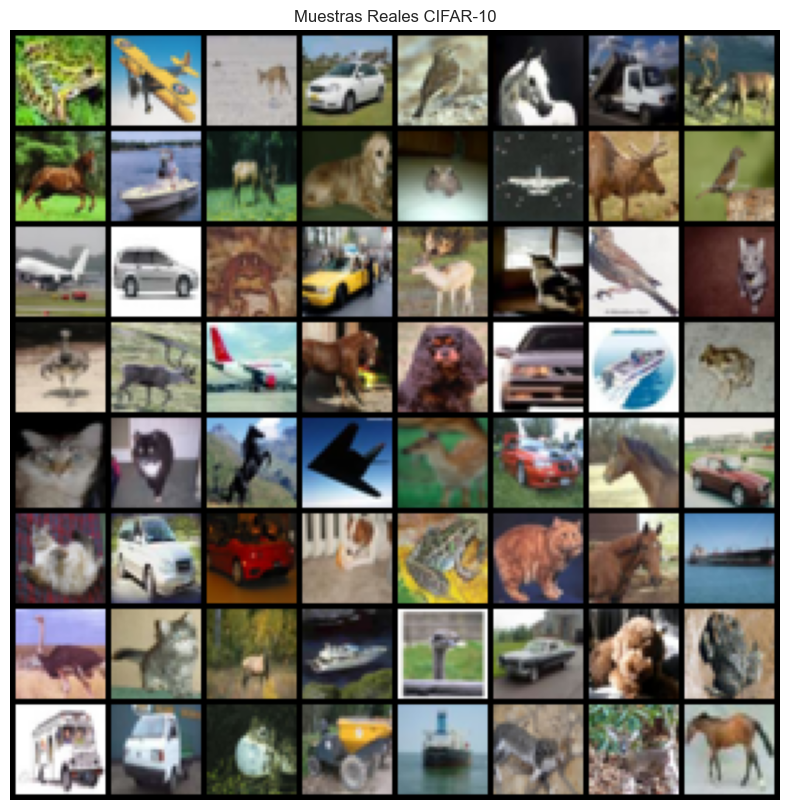

In [5]:
real_batch = next(iter(dataloader))[0]
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Muestras Reales CIFAR-10")
plt.imshow(np.transpose(
    vutils.make_grid(real_batch[:64], padding=2, normalize=True, nrow=8).cpu(),
    (1, 2, 0)
))
plt.show()

## Implementación de los modelos

### Generador (compartido por las 3 variantes)

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_features, num_channels):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, num_features * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 4, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 2, num_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, z):
        return self.main(z)

test_gen = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
test_z = torch.randn(1, LATENT_DIM, 1, 1, device=device)
test_out = test_gen(test_z)
print(f"Generator: {LATENT_DIM} → {test_out.shape[1]}x{test_out.shape[2]}x{test_out.shape[3]}")
del test_gen, test_z, test_out

Generator: 128 → 3x32x32


### Discriminador Vanilla GAN

In [ ]:
class VanillaDiscriminator(nn.Module):
    def __init__(self, num_channels, num_features):
        super(VanillaDiscriminator, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_disc = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_disc(test_img)
print(f"VanillaDiscriminator: → probabilidad [{test_out.item():.4f}] ∈ [0,1]")
del test_disc, test_img, test_out

### Critic WGAN/WGAN-GP

In [ ]:
class Critic(nn.Module):
    def __init__(self, num_channels, num_features):
        super(Critic, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

test_critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
test_img = torch.randn(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_out = test_critic(test_img)
print(f"Critic: → escalar sin bounds")
del test_critic, test_img, test_out

### Optimizador Vanilla GAN

In [ ]:
def get_vanilla_optimizers(generator, discriminator):
    optimizer_G = optim.SGD(generator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    optimizer_D = optim.SGD(discriminator.parameters(), lr=VANILLA_LR, momentum=VANILLA_MOMENTUM)
    return optimizer_G, optimizer_D

### Optimizador WGAN

In [10]:
def get_wgan_optimizers(generator, critic):
    optimizer_G = optim.RMSprop(generator.parameters(), lr=WGAN_LR)
    optimizer_C = optim.RMSprop(critic.parameters(), lr=WGAN_LR)
    return optimizer_G, optimizer_C

### Optimizador WGAN-GP

In [11]:
def get_wgangp_optimizers(generator, critic):
    optimizer_G = optim.Adam(generator.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    optimizer_C = optim.Adam(critic.parameters(), lr=WGANGP_LR, betas=WGANGP_BETAS)
    return optimizer_G, optimizer_C

### Loss Vanilla GAN

In [12]:
criterion_bce = nn.BCELoss()

### Loss WGAN

In [13]:
def wgan_critic_loss(critic_real, critic_fake):
    return -(critic_real - critic_fake)

def wgan_generator_loss(critic_fake):
    return -critic_fake

### Loss WGAN-GP

In [14]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)
    
    interpolated = alpha * real_samples + (1 - alpha) * fake_samples
    interpolated.requires_grad_(True)
    
    critic_interpolated = critic(interpolated)
    
    gradients = autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()
    
    return gradient_penalty

def wgangp_critic_loss(critic_real, critic_fake, gp):
    return -(critic_real - critic_fake) + WGANGP_LAMBDA * gp

def wgangp_generator_loss(critic_fake):
    return -critic_fake

### Utilidades compartidas

In [15]:
class TrainingMetrics:
    def __init__(self):
        self.critic_losses = []
        self.generator_losses = []
        self.wasserstein_distances = []
        self.gradient_norms = []
        self.weight_stats = []
        self.training_time = 0
        self.generated_samples = []
        self.iterations = []
    
    def log(self, iteration, c_loss, g_loss, w_dist):
        self.iterations.append(iteration)
        self.critic_losses.append(c_loss)
        self.generator_losses.append(g_loss)
        self.wasserstein_distances.append(w_dist)
    
    def log_gradients(self, critic_grads):
        total = sum(critic_grads.values())
        self.gradient_norms.append(total)
    
    def log_weights(self, critic_weights):
        self.weight_stats.append(critic_weights)
    
    def save_samples(self, samples):
        self.generated_samples.append(samples.detach().cpu())

def get_gradient_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.data.norm(2).item()
    return norms

def get_weight_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if 'weight' in name:
            stats[name] = {
                'min': param.data.min().item(),
                'max': param.data.max().item()
            }
    return stats

## Entrenamiento de los modelos

### Entrenamiento Vanilla GAN

In [ ]:
def train_vanilla_gan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name="Vanilla GAN", config={"modelo": "Vanilla GAN", "lr": VANILLA_LR, "momentum": VANILLA_MOMENTUM, "epocas": num_epochs})
    
    print(f"Entrenando Vanilla GAN: lr={VANILLA_LR}, momentum={VANILLA_MOMENTUM}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    discriminator = VanillaDiscriminator(NUM_CHANNELS, VANILLA_DISCRIMINATOR_FEATURES).to(device)
    optimizer_G, optimizer_D = get_vanilla_optimizers(generator, discriminator)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            optimizer_D.zero_grad()
            labels_real = torch.ones(batch_size, device=device)
            labels_fake = torch.zeros(batch_size, device=device)
            
            output_real = discriminator(real_images)
            d_loss_real = criterion_bce(output_real, labels_real)
            d_loss_real.backward()
            
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            output_fake = discriminator(fake_images.detach())
            d_loss_fake = criterion_bce(output_fake, labels_fake)
            d_loss_fake.backward()
            
            d_loss = d_loss_real + d_loss_fake
            optimizer_D.step()
            
            optimizer_G.zero_grad()
            output_fake_g = discriminator(fake_images)
            g_loss = criterion_bce(output_fake_g, labels_real)
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                w_dist = output_real.mean().item() - output_fake.mean().item()
                metrics.log(iteration, d_loss.item(), g_loss.item(), w_dist)
                metrics.log_gradients(get_gradient_norms(discriminator))
                
                if USE_WANDB:
                    wandb.log({"loss_D": d_loss.item(), "loss_G": g_loss.item(), "W-dist": w_dist})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        if epoch == num_epochs - 1:
            metrics.log_weights(get_weight_stats(discriminator))
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, discriminator, metrics

In [17]:
vanilla_gen, vanilla_disc, vanilla_metrics = train_vanilla_gan(dataloader, NUM_EPOCHS)

Entrenando Vanilla GAN: lr=0.0002, épocas=1
Época 1/1
Completado: 0.15 min


### Entrenamiento WGAN

In [ ]:
def train_wgan(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN (c={WGAN_CLIP})", config={"modelo": "WGAN", "lr": WGAN_LR, "clip": WGAN_CLIP})
    
    print(f"Entrenando WGAN: lr={WGAN_LR}, c={WGAN_CLIP}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGAN_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgan_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGAN_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z).detach()
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                
                c_loss = wgan_critic_loss(critic_real, critic_fake)
                c_loss.backward()
                optimizer_C.step()
                
                for p in critic.parameters():
                    p.data.clamp_(-WGAN_CLIP, WGAN_CLIP)
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgan_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                w_dist = critic_real.item() - critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), w_dist)
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "W-dist": w_dist})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        if epoch == num_epochs - 1:
            metrics.log_weights(get_weight_stats(critic))
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [19]:
wgan_gen, wgan_critic, wgan_metrics = train_wgan(dataloader, NUM_EPOCHS)

Entrenando WGAN: lr=5e-05, c=0.01, épocas=1
Época 1/1
Completado: 0.42 min


### Entrenamiento WGAN-GP

In [ ]:
def train_wgangp(dataloader, num_epochs, log_interval=100):
    if USE_WANDB:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
                   name=f"WGAN-GP (λ={WGANGP_LAMBDA})", config={"modelo": "WGAN-GP", "lr": WGANGP_LR, "lambda": WGANGP_LAMBDA})
    
    print(f"Entrenando WGAN-GP: lr={WGANGP_LR}, λ={WGANGP_LAMBDA}, épocas={num_epochs}")
    
    generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
    critic = Critic(NUM_CHANNELS, WGANGP_CRITIC_FEATURES).to(device)
    optimizer_G, optimizer_C = get_wgangp_optimizers(generator, critic)
    
    metrics = TrainingMetrics()
    fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    start_time = time.time()
    iteration = 0
    
    for epoch in range(num_epochs):
        for real_images, _ in dataloader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            for _ in range(WGANGP_CRITIC_ITERATIONS):
                optimizer_C.zero_grad()
                
                z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
                fake_images = generator(z)
                
                critic_real = critic(real_images).mean()
                critic_fake = critic(fake_images).mean()
                gp = compute_gradient_penalty(critic, real_images, fake_images, device)
                
                c_loss = wgangp_critic_loss(critic_real, critic_fake, gp)
                c_loss.backward()
                optimizer_C.step()
            
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            g_loss = wgangp_generator_loss(critic(fake_images).mean())
            g_loss.backward()
            optimizer_G.step()
            
            if iteration % log_interval == 0:
                w_dist = critic_real.item() - critic_fake.item()
                metrics.log(iteration, c_loss.item(), g_loss.item(), w_dist)
                metrics.log_gradients(get_gradient_norms(critic))
                
                if USE_WANDB:
                    wandb.log({"loss_C": c_loss.item(), "loss_G": g_loss.item(), "W-dist": w_dist, "GP": gp.item()})
            
            iteration += 1
        
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            metrics.save_samples(fake_samples)
            if USE_WANDB:
                wandb.log({"samples": wandb.Image(vutils.make_grid(fake_samples[:16], normalize=True))})
        
        if epoch == num_epochs - 1:
            metrics.log_weights(get_weight_stats(critic))
        
        print(f"\rÉpoca {epoch+1}/{num_epochs}", end='', flush=True)
    
    print()
    metrics.training_time = time.time() - start_time
    if USE_WANDB:
        wandb.finish()
    
    print(f"Completado: {metrics.training_time/60:.2f} min")
    return generator, critic, metrics

In [21]:
wgangp_gen, wgangp_critic, wgangp_metrics = train_wgangp(dataloader, NUM_EPOCHS)

Entrenando WGAN-GP: lr=0.0001, λ=10, épocas=1
Época 1/1
Completado: 0.83 min


## Evaluación de los modelos

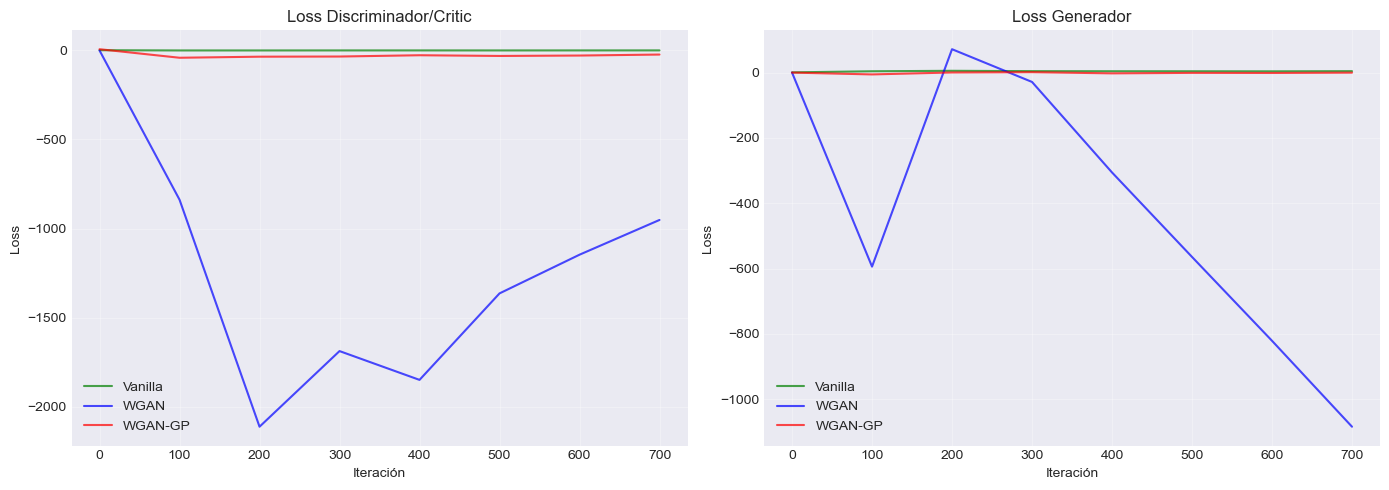

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vanilla_metrics.iterations, vanilla_metrics.critic_losses, label='Vanilla', color='green', alpha=0.7)
axes[0].plot(wgan_metrics.iterations, wgan_metrics.critic_losses, label='WGAN', color='blue', alpha=0.7)
axes[0].plot(wgangp_metrics.iterations, wgangp_metrics.critic_losses, label='WGAN-GP', color='red', alpha=0.7)
axes[0].set_title('Loss Discriminador/Critic')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(vanilla_metrics.iterations, vanilla_metrics.generator_losses, label='Vanilla', color='green', alpha=0.7)
axes[1].plot(wgan_metrics.iterations, wgan_metrics.generator_losses, label='WGAN', color='blue', alpha=0.7)
axes[1].plot(wgangp_metrics.iterations, wgangp_metrics.generator_losses, label='WGAN-GP', color='red', alpha=0.7)
axes[1].set_title('Loss Generador')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/losses.png', dpi=150)
plt.show()

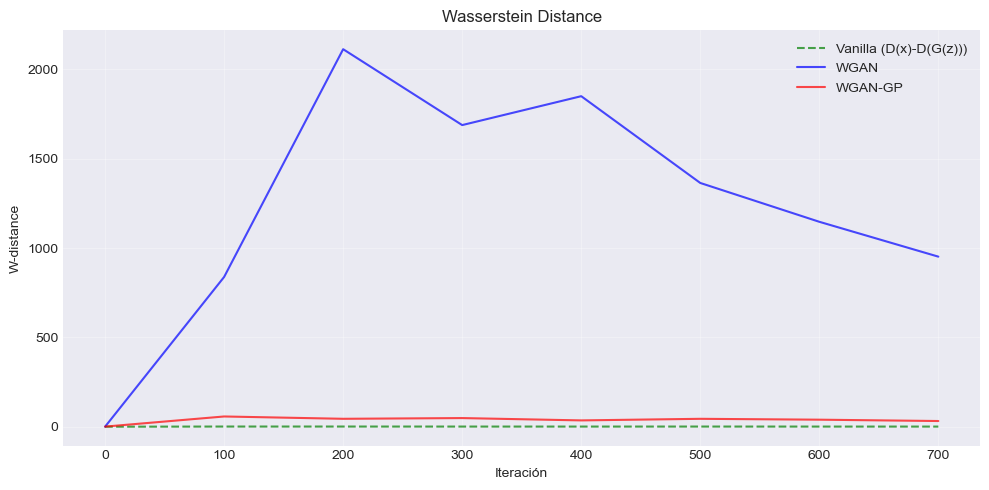

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(vanilla_metrics.iterations, vanilla_metrics.wasserstein_distances, label='Vanilla (D(x)-D(G(z)))', color='green', alpha=0.7, linestyle='--')
plt.plot(wgan_metrics.iterations, wgan_metrics.wasserstein_distances, label='WGAN', color='blue', alpha=0.7)
plt.plot(wgangp_metrics.iterations, wgangp_metrics.wasserstein_distances, label='WGAN-GP', color='red', alpha=0.7)
plt.title('Wasserstein Distance')
plt.xlabel('Iteración')
plt.ylabel('W-distance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/wasserstein.png', dpi=150)
plt.show()

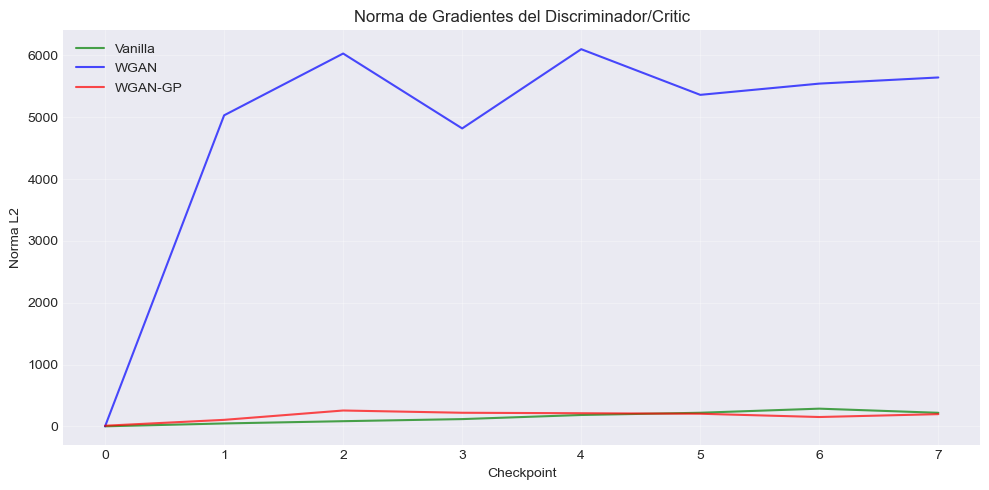


Estabilidad de gradientes (menor varianza = más estable):
  Vanilla: var=8442.05
  WGAN:    var=3480831.13
  WGAN-GP: var=5463.59


In [24]:
plt.figure(figsize=(10, 5))
plt.plot(vanilla_metrics.gradient_norms, label='Vanilla', color='green', alpha=0.7)
plt.plot(wgan_metrics.gradient_norms, label='WGAN', color='blue', alpha=0.7)
plt.plot(wgangp_metrics.gradient_norms, label='WGAN-GP', color='red', alpha=0.7)
plt.title('Norma de Gradientes del Discriminador/Critic')
plt.xlabel('Checkpoint')
plt.ylabel('Norma L2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/gradients.png', dpi=150)
plt.show()

print("\nEstabilidad de gradientes (menor varianza = más estable):")
print(f"  Vanilla: var={np.var(vanilla_metrics.gradient_norms):.2f}")
print(f"  WGAN:    var={np.var(wgan_metrics.gradient_norms):.2f}")
print(f"  WGAN-GP: var={np.var(wgangp_metrics.gradient_norms):.2f}")

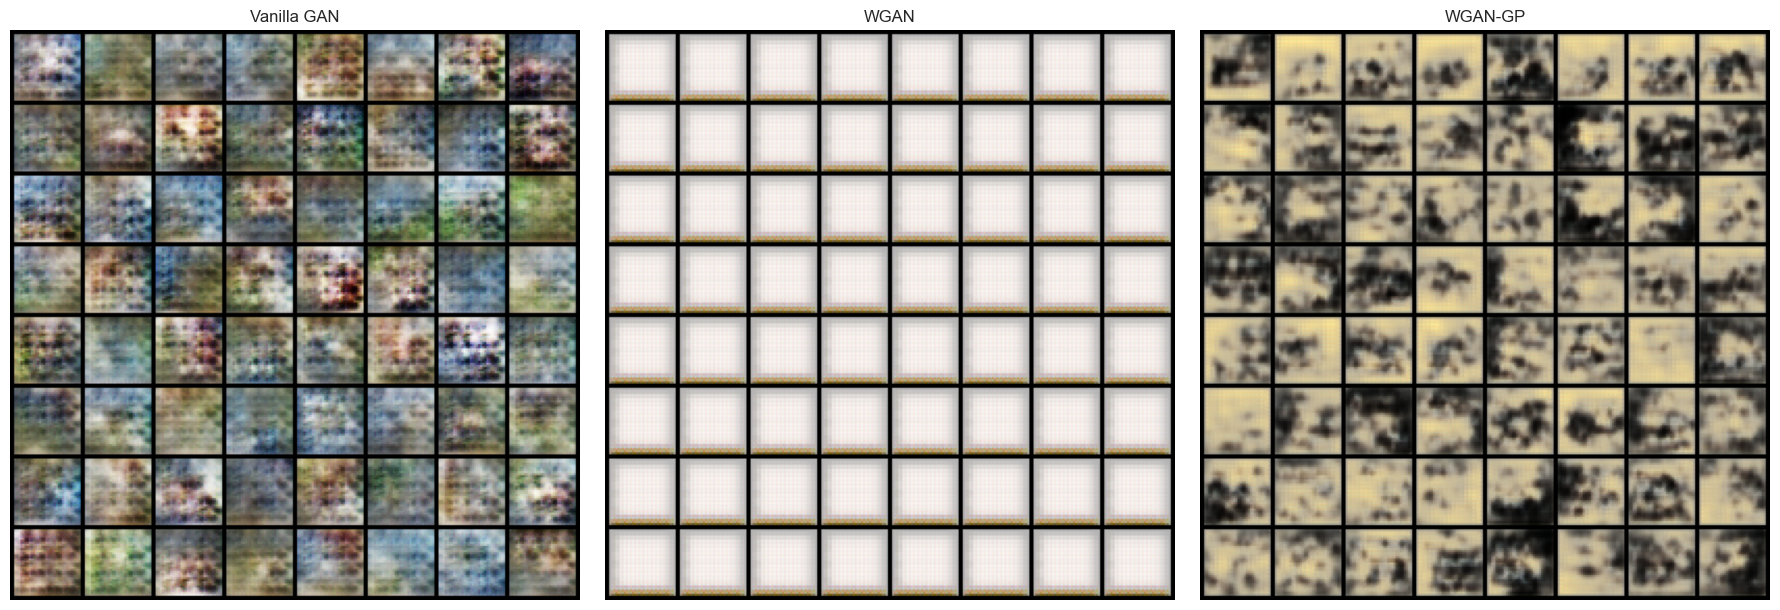

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vanilla_grid = vutils.make_grid(vanilla_metrics.generated_samples[-1][:64], padding=2, normalize=True, nrow=8)
axes[0].imshow(np.transpose(vanilla_grid.numpy(), (1, 2, 0)))
axes[0].set_title('Vanilla GAN')
axes[0].axis('off')

wgan_grid = vutils.make_grid(wgan_metrics.generated_samples[-1][:64], padding=2, normalize=True, nrow=8)
axes[1].imshow(np.transpose(wgan_grid.numpy(), (1, 2, 0)))
axes[1].set_title('WGAN')
axes[1].axis('off')

wgangp_grid = vutils.make_grid(wgangp_metrics.generated_samples[-1][:64], padding=2, normalize=True, nrow=8)
axes[2].imshow(np.transpose(wgangp_grid.numpy(), (1, 2, 0)))
axes[2].set_title('WGAN-GP')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/samples.png', dpi=150)
plt.show()

## Métricas finales

In [26]:
print("="*70)
print("RESUMEN FINAL")
print("="*70)

print("\nTiempos de entrenamiento:")
print(f"  Vanilla GAN: {vanilla_metrics.training_time/60:.2f} min")
print(f"  WGAN:        {wgan_metrics.training_time/60:.2f} min")
print(f"  WGAN-GP:     {wgangp_metrics.training_time/60:.2f} min")

print("\nWasserstein distance final:")
print(f"  Vanilla GAN: {vanilla_metrics.wasserstein_distances[-1]:.4f}")
print(f"  WGAN:        {wgan_metrics.wasserstein_distances[-1]:.4f}")
print(f"  WGAN-GP:     {wgangp_metrics.wasserstein_distances[-1]:.4f}")

if vanilla_metrics.weight_stats and wgan_metrics.weight_stats and wgangp_metrics.weight_stats:
    v_w = vanilla_metrics.weight_stats[-1]
    w_w = wgan_metrics.weight_stats[-1]
    g_w = wgangp_metrics.weight_stats[-1]
    first_layer = list(w_w.keys())[0]
    
    print("\nRango de pesos (primera capa):")
    print(f"  Vanilla GAN: [{v_w[first_layer]['min']:.4f}, {v_w[first_layer]['max']:.4f}]")
    print(f"  WGAN:        [{w_w[first_layer]['min']:.4f}, {w_w[first_layer]['max']:.4f}]")
    print(f"  WGAN-GP:     [{g_w[first_layer]['min']:.4f}, {g_w[first_layer]['max']:.4f}]")

print("\n" + "="*70)

RESUMEN FINAL

Tiempos de entrenamiento:
  Vanilla GAN: 0.15 min
  WGAN:        0.42 min
  WGAN-GP:     0.83 min

Wasserstein distance final:
  Vanilla GAN: 0.6817
  WGAN:        951.9110
  WGAN-GP:     31.8157

Rango de pesos (primera capa):
  Vanilla GAN: [-0.0787, 0.0725]
  WGAN:        [0.0100, 0.0100]
  WGAN-GP:     [-0.0754, 0.0818]



In [27]:
torch.save(vanilla_gen.state_dict(), f'{MODELS_DIR}/vanilla_gen.pth')
torch.save(vanilla_disc.state_dict(), f'{MODELS_DIR}/vanilla_disc.pth')
torch.save(wgan_gen.state_dict(), f'{MODELS_DIR}/wgan_gen.pth')
torch.save(wgan_critic.state_dict(), f'{MODELS_DIR}/wgan_critic.pth')
torch.save(wgangp_gen.state_dict(), f'{MODELS_DIR}/wgangp_gen.pth')
torch.save(wgangp_critic.state_dict(), f'{MODELS_DIR}/wgangp_critic.pth')

print(f"Modelos guardados en: {MODELS_DIR}")

Modelos guardados en: ./outputs/wgan_comparison_20251205_002012/models


## Conclusiones

[A COMPLETAR]

---

### Referencias

1. Goodfellow, I., et al. (2014). Generative Adversarial Nets. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)
2. Arjovsky, M., et al. (2017). Wasserstein GAN. [arXiv:1701.07875](https://arxiv.org/abs/1701.07875)
3. Gulrajani, I., et al. (2017). Improved Training of Wasserstein GANs. [arXiv:1704.00028](https://arxiv.org/abs/1704.00028)